In [3]:
import pypsa
from matplotlib import pyplot as plt
import cartopy.crs as ccrs
import numpy as np
import geopandas as gpd
import pandas as pd
import os
# Line2D
from matplotlib.lines import Line2D
from matplotlib.colors import TwoSlopeNorm


In [4]:
TITLE_SIZE = 20

In [5]:
# BAU
sub_folder = '5_8_BAU'
n_cp_reactive = pypsa.Network(f'/Users/kamrantehranchi/Local_Documents/pypsa-usa/workflow/notebooks/CH2/{sub_folder}/elec_s210_cl0a_ch180a_ec_lv1.0_3h_E_mapped_TEP.nc')
n_hr_reactive = pypsa.Network(f'/Users/kamrantehranchi/Local_Documents/pypsa-usa/workflow/notebooks/CH2/{sub_folder}/elec_s210_cl180a_ch180a_ec_lv1.0_3h_E_mapped_TEP.nc')
n_lr_reactive = pypsa.Network(f'/Users/kamrantehranchi/Local_Documents/pypsa-usa/workflow/notebooks/CH2/{sub_folder}/elec_s210_cl7a_ch180a_ec_lv1.0_3h_E_mapped_TEP.nc')
n_lr_proactive = pypsa.Network(f"/Users/kamrantehranchi/Local_Documents/pypsa-usa/workflow/notebooks/CH2/{sub_folder}/elec_s210_cl7a_ch180a_ec_lvopt_3h_E_mapped_TEP.nc")
n_hr_proactive = pypsa.Network(f'/Users/kamrantehranchi/Local_Documents/pypsa-usa/workflow/notebooks/CH2/{sub_folder}/elec_s210_c180a_ec_lvopt_3h_E.nc')

INFO:pypsa.io:Imported network elec_s210_cl0a_ch180a_ec_lv1.0_3h_E_mapped_TEP.nc has buses, carriers, generators, lines, loads, storage_units
INFO:pypsa.io:Imported network elec_s210_cl180a_ch180a_ec_lv1.0_3h_E_mapped_TEP.nc has buses, carriers, generators, lines, loads, storage_units
INFO:pypsa.io:Imported network elec_s210_cl7a_ch180a_ec_lv1.0_3h_E_mapped_TEP.nc has buses, carriers, generators, lines, loads, storage_units
INFO:pypsa.io:Imported network elec_s210_cl7a_ch180a_ec_lvopt_3h_E_mapped_TEP.nc has buses, carriers, generators, lines, loads, storage_units
INFO:pypsa.io:Imported network elec_s210_c180a_ec_lvopt_3h_E.nc has buses, carriers, generators, lines, loads, storage_units


In [6]:
n_lr_reactive

PyPSA Network
Components:
 - Bus: 180
 - Carrier: 18
 - Generator: 1412
 - Line: 489
 - Load: 180
 - StorageUnit: 242
Snapshots: 2920

In [ ]:
# # REM
# sub_folder = '5_8_REM'

# n_cp_reactive_rem = pypsa.Network(f'/Users/kamrantehranchi/Local_Documents/pypsa-usa/workflow/notebooks/CH2/{sub_folder}/elec_s210_cl0a_ch180a_ec_lv1.0_REM-3h_E_mapped_TEP.nc')
# n_hr_reactive_rem = pypsa.Network(f'/Users/kamrantehranchi/Local_Documents/pypsa-usa/workflow/notebooks/CH2/{sub_folder}/elec_s210_cl180a_ch180a_ec_lv1.0_REM-3h_E_mapped_TEP.nc')
# n_lr_reactive_rem = pypsa.Network(f'/Users/kamrantehranchi/Local_Documents/pypsa-usa/workflow/notebooks/CH2/{sub_folder}/elec_s210_cl7a_ch180a_ec_lv1.0_REM-3h_E_mapped_TEP.nc')
# n_lr_proactive_rem = pypsa.Network(f"/Users/kamrantehranchi/Local_Documents/pypsa-usa/workflow/notebooks/CH2/{sub_folder}/elec_s210_cl7a_ch180a_ec_lvopt_REM-3h_E_mapped_TEP.nc")
# n_hr_proactive_rem = pypsa.Network(f'/Users/kamrantehranchi/Local_Documents/pypsa-usa/workflow/notebooks/CH2/{sub_folder}/elec_s210_c180a_ec_lvopt_REM-3h_E.nc')

In [7]:
regions = gpd.read_file("/Users/kamrantehranchi/Local_Documents/pypsa-usa/workflow/notebooks/CH2/TexasGeospatial/regions_onshore_s210.geojson")
regions_lr = gpd.read_file('/Users/kamrantehranchi/Local_Documents/pypsa-usa/workflow/notebooks/CH2/TexasGeospatial/regions_onshore_s210_7a.geojson')

In [8]:
def plot_capacity_map(
    n: pypsa.Network,
    bus_values: pd.DataFrame,
    line_values: pd.DataFrame,
    link_values: pd.DataFrame,
    regions: gpd.GeoDataFrame,
    ax: plt.axes,
    bus_scale=1,
    line_scale=1,
    title=None,
    flow=None,
    line_colors="teal",
    link_colors="green",
    line_cmap="viridis",
    line_norm=None,
    line_alpha=0.5,
    bus_split_circles=False,
) -> plt.axes:
    """Generic network plotting function for capacity pie charts at each node."""
    line_width = line_values / line_scale
    link_width = link_values / line_scale

    with plt.rc_context({"patch.linewidth": 0.1}):
        n.plot(
            bus_sizes=bus_values / bus_scale,
            bus_colors=n.carriers.color,
            bus_alpha=0.7,
            line_widths=line_width,
            link_widths=0 if link_width.empty else link_width,
            line_colors=line_colors,
            link_colors=link_colors,
            ax=ax,
            margin=0.2,
            color_geomap=True,
            flow=flow,
            line_cmap=line_cmap,
            line_norm=line_norm,
            line_alpha=line_alpha,
            bus_split_circles=bus_split_circles,
        )

    # onshore regions
    regions.boundary.plot(
        ax=ax,
        facecolor="gainsboro",
        edgecolor="white",
        aspect="equal",
        transform=ccrs.PlateCarree(),
        linewidth=1.2,
    )
    ax.set_extent(regions.total_bounds[[0, 2, 1, 3]])

    ax.set_title(title or "Capacity (MW)", fontsize=TITLE_SIZE, pad=20)

    return ax


def plot_network_capacity(
    n: pypsa.Network,
    ax: plt.axes,
    regions: gpd.GeoDataFrame,
    plot_type: str = "base",
    bus_scale: float = 1e3,
    line_scale: float = 1e6,
    line_colors: str ="teal",
    link_colors: str="green",
    line_alpha: float = 0.5,
) -> plt.axes:
    """Plot network capacity for buses, lines, and links.".
    
    Options for plot_type:
    - base: Base network capacities
    - opt: Optimal network capacities
    - new: New network capacities
    """
    groupers = n.statistics.groupers

    if plot_type == "base":
        bus_groups = n.statistics.installed_capacity(groupby=groupers.get_bus_and_carrier, nice_names=False)
        bus_groups = bus_groups[bus_groups.index.get_level_values('component') != 'Line']
        bus_groups = bus_groups.droplevel(0)
        bus_values= bus_groups[n.investment_periods[0]]

        line_values = n.lines.s_nom
        link_values = n.links[n.links.carrier == "AC"].p_nom.replace(to_replace={pd.NA: 0})
        title = "Base Network Capacities"
    
    elif plot_type == "opt":
        bus_groups = n.statistics.optimal_capacity(groupby=groupers.get_bus_and_carrier, nice_names=False)
        bus_groups = bus_groups[bus_groups.index.get_level_values('component') != 'Line']
        bus_groups = bus_groups.droplevel(0)
        bus_values= bus_groups[n.investment_periods[0]]

        line_values = n.lines.s_nom_opt
        link_values = n.links[n.links.carrier == "AC"].p_nom_opt.replace(to_replace={pd.NA: 0})
        title = "Optimal Network Capacities"
    
    elif plot_type == "new":
        bus_pnom = n.statistics.installed_capacity(groupby=groupers.get_bus_and_carrier, nice_names=False)
        bus_pnom = bus_pnom[bus_pnom.index.get_level_values('component') != 'Line']
        bus_pnom = bus_pnom.droplevel(0)


        bus_pnom_opt = n.statistics.optimal_capacity(groupby=groupers.get_bus_and_carrier, nice_names=False)
        bus_pnom_opt = bus_pnom_opt[bus_pnom_opt.index.get_level_values('component') != 'Line']
        bus_pnom_opt = bus_pnom_opt.droplevel(0)

        bus_values = bus_pnom_opt - bus_pnom
        bus_values = bus_values[(bus_values > 0)]
        bus_values= bus_values[n.investment_periods[0]]

        
        line_values = n.lines.s_nom_opt - n.lines.s_nom
        link_pnom = n.links[n.links.carrier == "AC"].p_nom
        link_pnom_opt = n.links[n.links.carrier == "AC"].p_nom_opt
        link_values = link_pnom_opt - link_pnom
        link_values = link_values.replace(to_replace={pd.NA: 0})
        title = "New Network Capacities"
    
    else:
        raise ValueError(f"Unknown plot_type: {plot_type}")

    # Plot data
    plot_capacity_map(
        n=n,
        bus_values=bus_values,
        line_values=line_values,
        link_values=link_values,
        regions=regions,
        ax=ax,
        line_scale=line_scale,
        bus_scale=bus_scale,
        title=title,
        line_colors=line_colors,
        link_colors=link_colors,
        line_alpha=line_alpha,
    )
    return ax

# Transmission Comparisons

In [9]:
def get_diff_capacities(n: pypsa.Network):
    groupers = n.statistics.groupers
    bus_pnom = n.statistics.installed_capacity(groupby=groupers.get_bus_and_carrier, nice_names=False)
    bus_pnom = bus_pnom[bus_pnom.index.get_level_values('component') != 'Line']
    bus_pnom = bus_pnom.droplevel(0)


    bus_pnom_opt = n.statistics.optimal_capacity(groupby=groupers.get_bus_and_carrier, nice_names=False)
    bus_pnom_opt = bus_pnom_opt[bus_pnom_opt.index.get_level_values('component') != 'Line']
    bus_pnom_opt = bus_pnom_opt.droplevel(0)

    bus_values = bus_pnom_opt.fillna(0) - bus_pnom.fillna(0)
    bus_values= bus_values[n.investment_periods[0]]


    line_values = n.lines.s_nom_opt - n.lines.s_nom
    link_pnom = n.links[n.links.carrier == "AC"].p_nom
    link_pnom_opt = n.links[n.links.carrier == "AC"].p_nom_opt
    link_values = link_pnom_opt - link_pnom
    link_values = link_values.replace(to_replace={pd.NA: 0})
    return bus_values, line_values, link_values


## Low-Res Reactive vs. High-Res Proactive

/Users/kamrantehranchi/miniforge3/envs/pypsa-usa/lib/python3.11/site-packages/pypsa/statistics/grouping.py:381: DeprecationWarning:

`n.statistics.get_bus_and_carrier` and `pypsa.statistics.get_bus_and_carrier` are deprecated. Use `pypsa.statistics.groupers["bus", "carrier"]` instead.

/Users/kamrantehranchi/miniforge3/envs/pypsa-usa/lib/python3.11/site-packages/pypsa/statistics/grouping.py:381: DeprecationWarning:

`n.statistics.get_bus_and_carrier` and `pypsa.statistics.get_bus_and_carrier` are deprecated. Use `pypsa.statistics.groupers["bus", "carrier"]` instead.

/Users/kamrantehranchi/miniforge3/envs/pypsa-usa/lib/python3.11/site-packages/pypsa/statistics/grouping.py:381: DeprecationWarning:

`n.statistics.get_bus_and_carrier` and `pypsa.statistics.get_bus_and_carrier` are deprecated. Use `pypsa.statistics.groupers["bus", "carrier"]` instead.

/Users/kamrantehranchi/miniforge3/envs/pypsa-usa/lib/python3.11/site-packages/pypsa/statistics/grouping.py:381: DeprecationWarning:

`n.sta

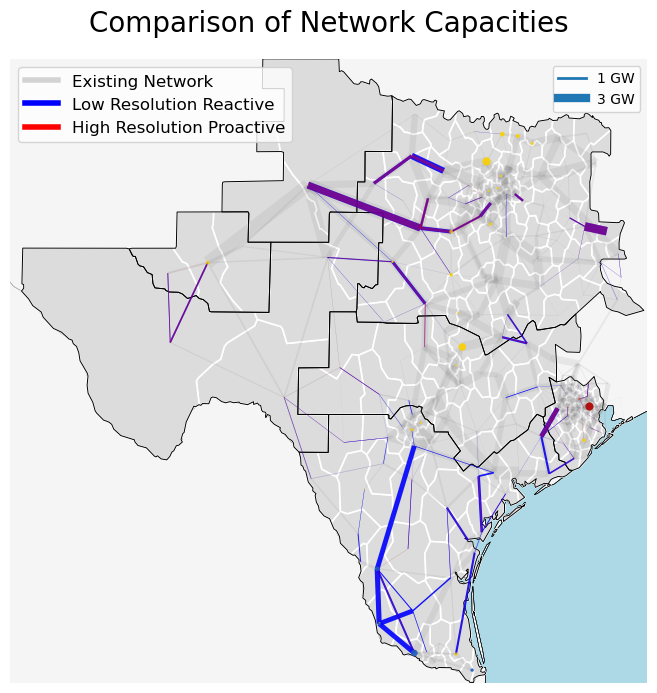

In [10]:
fig, axes = plt.subplots(1, 1, figsize=(7 , 7), subplot_kw={"projection": ccrs.EqualEarth(n_lr_reactive.buses.x.mean())})

line_scale = 5e2
bus_scale = 1e6

plot_network_capacity(
    n_hr_proactive,
    ax=axes,
    regions=regions,
    plot_type='base',
    bus_scale = 1e10,
    line_scale= line_scale,
    line_colors="dimgrey", 
    link_colors="dimgrey",
    line_alpha=0.1,
) 

SQ_color = "blue"
ID_color = "red"

plot_network_capacity(
    n_lr_reactive,
    ax=axes,
    regions=regions,
    plot_type='new',
    bus_scale = bus_scale,
    line_scale= line_scale,
    line_colors=SQ_color, 
    link_colors=SQ_color,
    line_alpha=0.9,
) 

plot_network_capacity(
    n_hr_proactive,
    ax=axes,
    regions=regions,
    plot_type='new',
    bus_scale = bus_scale,
    line_scale= line_scale,
    line_colors=ID_color, 
    link_colors=ID_color,
    line_alpha=0.4,
) 

pypsa.plot.add_legend_lines(axes, sizes=[1e3/line_scale, 3e3/line_scale], labels=["1 GW", "3 GW"])
legend_elements = [
    Line2D([0], [0], color='lightgrey', lw=4, label='Existing Network'),
    Line2D([0], [0], color=SQ_color, lw=4, label='Low Resolution Reactive'),
    Line2D([0], [0], color=ID_color, lw=4, label='High Resolution Proactive'),
]
axes.legend(handles=legend_elements, loc='upper left', fontsize=TITLE_SIZE * 0.6)

regions_lr.boundary.plot(
    ax=axes,
    facecolor=None,
    edgecolor="black",
    aspect="equal",
    transform=ccrs.PlateCarree(),
    linewidth=0.7,
)

plt.title("Comparison of Network Capacities", fontsize=TITLE_SIZE, pad=20)
fig.tight_layout()

# Multi-plot

/Users/kamrantehranchi/miniforge3/envs/pypsa-usa/lib/python3.11/site-packages/pypsa/statistics/grouping.py:381: DeprecationWarning:

`n.statistics.get_bus_and_carrier` and `pypsa.statistics.get_bus_and_carrier` are deprecated. Use `pypsa.statistics.groupers["bus", "carrier"]` instead.

/Users/kamrantehranchi/miniforge3/envs/pypsa-usa/lib/python3.11/site-packages/pypsa/statistics/grouping.py:381: DeprecationWarning:

`n.statistics.get_bus_and_carrier` and `pypsa.statistics.get_bus_and_carrier` are deprecated. Use `pypsa.statistics.groupers["bus", "carrier"]` instead.

/Users/kamrantehranchi/miniforge3/envs/pypsa-usa/lib/python3.11/site-packages/pypsa/statistics/grouping.py:381: DeprecationWarning:

`n.statistics.get_bus_and_carrier` and `pypsa.statistics.get_bus_and_carrier` are deprecated. Use `pypsa.statistics.groupers["bus", "carrier"]` instead.

/Users/kamrantehranchi/miniforge3/envs/pypsa-usa/lib/python3.11/site-packages/pypsa/statistics/grouping.py:381: DeprecationWarning:

`n.sta

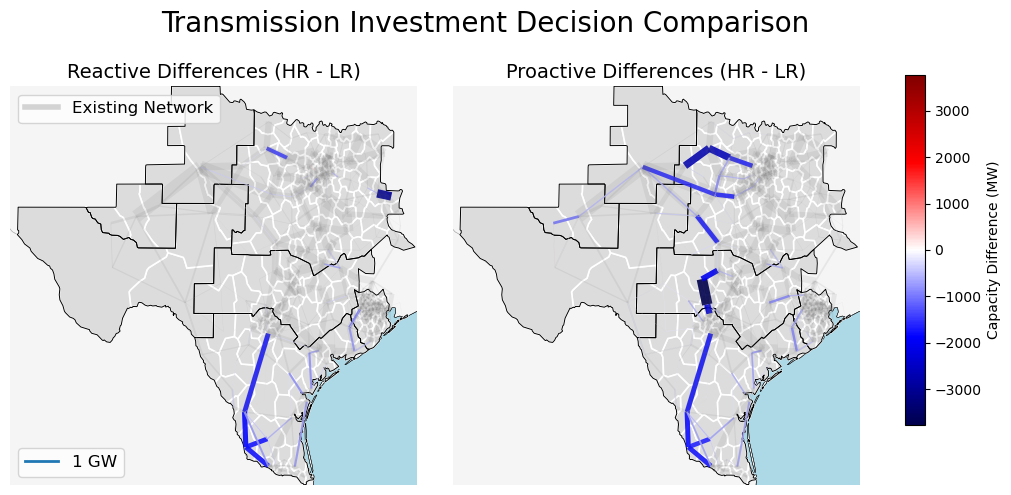

In [23]:
# Reactive differences
hr_reac_bus_diff, hr_reac_line_diff, hr_reac_link_diff = get_diff_capacities(n_hr_reactive)
lr_reac_bus_diff, lr_reac_line_diff, lr_reac_link_diff = get_diff_capacities(n_lr_reactive)
diff_bus_reactive = hr_reac_bus_diff - lr_reac_bus_diff
diff_line_reactive = hr_reac_line_diff - lr_reac_line_diff
diff_link_reactive = hr_reac_link_diff - lr_reac_link_diff

# Proactive differences
hr_pro_bus_diff, hr_pro_line_diff, hr_pro_link_diff = get_diff_capacities(n_hr_proactive)
lr_pro_bus_diff, lr_pro_line_diff, lr_pro_link_diff = get_diff_capacities(n_lr_proactive)
diff_bus_proactive = hr_pro_bus_diff - lr_pro_bus_diff

# proactive - reactive investments
diff_line_proactive = hr_pro_line_diff - lr_pro_line_diff
diff_link_proactive = hr_pro_link_diff - lr_pro_link_diff

# Create a list of dictionaries for each subplot
subplot_data = [
    {
        'title': 'Reactive Differences (HR - LR)',
        'bus_values': diff_bus_reactive,
        'line_values': diff_line_reactive,
        'link_values': diff_link_reactive
    },
    {
        'title': 'Proactive Differences (HR - LR)',
        'bus_values': diff_bus_proactive,
        'line_values': diff_line_proactive, 
        'link_values': diff_link_proactive
    },
]


# Common parameters
line_colors = "purple"
link_colors = "purple"
line_alpha = 0.9
colormap = "seismic"
line_scale = 5e2
bus_scale = 1e10

# Create figure with subplots
fig, axes = plt.subplots(1, 2, figsize=(10, 5), 
                         subplot_kw={"projection": ccrs.EqualEarth(n_lr_reactive.buses.x.mean())})

# Find the maximum absolute value across all data for consistent color scaling
vmax = max([
    max(abs(data['line_values'].min()), abs(data['line_values'].max())) 
    for data in subplot_data
])
norm = TwoSlopeNorm(vmin=-vmax, vcenter=0, vmax=vmax)

# Plot each subplot
for i, (ax, data) in enumerate(zip(axes, subplot_data)):
    # Plot capacity map
    plot_capacity_map(
        n=n_lr_reactive,
        bus_values=data['bus_values'],
        line_values=data['line_values'],
        link_values=data['link_values'],
        regions=regions,
        ax=ax,
        line_scale=line_scale,
        bus_scale=bus_scale,
        title=None,  # We'll set title separately
        line_colors=data['line_values'],
        line_cmap=colormap,
        link_colors=link_colors,
        line_alpha=line_alpha,
        line_norm=norm,  # Use the same norm for all subplots
        bus_split_circles=True
    )
    
    # Plot network base
    plot_network_capacity(
        n_lr_reactive,
        ax=ax,
        regions=regions,
        plot_type='base',
        bus_scale=10e20,
        line_scale=line_scale,
        line_colors="dimgrey",
        link_colors="dimgrey",
        line_alpha=0.1,
    )
    
    # Add region boundaries
    regions_lr.boundary.plot(
        ax=ax,
        facecolor=None,
        edgecolor="black",
        aspect="equal",
        transform=ccrs.PlateCarree(),
        linewidth=0.7,
    )
    
    # Set subplot title
    ax.set_title(data['title'], fontsize=TITLE_SIZE * 0.7)
    
    # Only add legend to the first subplot
    if i == 0:
        pypsa.plot.add_legend_lines(
            ax, 
            sizes=[1e3/line_scale], 
            labels=["1 GW"], legend_kw={"loc": "lower left", "fontsize": TITLE_SIZE * 0.6}
        )
        legend_elements = [
            Line2D([0], [0], color='lightgrey', lw=4, label='Existing Network'),
        ]
        ax.legend(handles=legend_elements, loc='upper left', fontsize=TITLE_SIZE * 0.6)

# Create a ScalarMappable for the colorbar
sm = plt.cm.ScalarMappable(cmap=colormap, norm=norm)
sm._A = []

# Add a colorbar that applies to all subplots
cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])  # [left, bottom, width, height]
cbar = fig.colorbar(sm, cax=cbar_ax, orientation='vertical')
cbar.set_label('Capacity Difference (MW)', fontsize=TITLE_SIZE * 0.5)

# Add main title
plt.suptitle("Transmission Investment Decision Comparison", fontsize=TITLE_SIZE)

# Adjust layout
fig.tight_layout(rect=[0, 0, 0.9, 0.95])  # Make room for colorbar

plt.show()

/Users/kamrantehranchi/miniforge3/envs/pypsa-usa/lib/python3.11/site-packages/pypsa/statistics/grouping.py:381: DeprecationWarning:

`n.statistics.get_bus_and_carrier` and `pypsa.statistics.get_bus_and_carrier` are deprecated. Use `pypsa.statistics.groupers["bus", "carrier"]` instead.

/Users/kamrantehranchi/miniforge3/envs/pypsa-usa/lib/python3.11/site-packages/pypsa/statistics/grouping.py:381: DeprecationWarning:

`n.statistics.get_bus_and_carrier` and `pypsa.statistics.get_bus_and_carrier` are deprecated. Use `pypsa.statistics.groupers["bus", "carrier"]` instead.

/Users/kamrantehranchi/miniforge3/envs/pypsa-usa/lib/python3.11/site-packages/pypsa/statistics/grouping.py:381: DeprecationWarning:

`n.statistics.get_bus_and_carrier` and `pypsa.statistics.get_bus_and_carrier` are deprecated. Use `pypsa.statistics.groupers["bus", "carrier"]` instead.

/Users/kamrantehranchi/miniforge3/envs/pypsa-usa/lib/python3.11/site-packages/pypsa/statistics/grouping.py:381: DeprecationWarning:

`n.sta

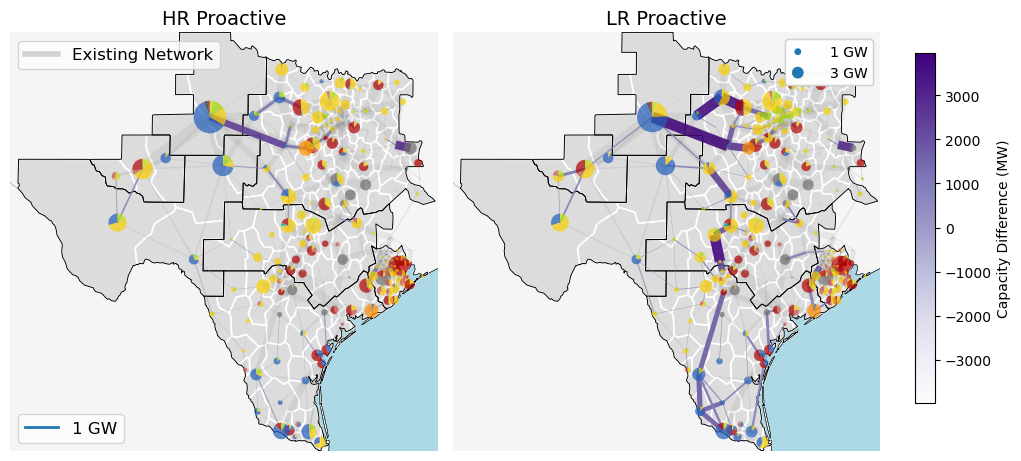

In [47]:
# Proactive differences
hr_pro_bus_diff, hr_pro_line_diff, hr_pro_link_diff = get_diff_capacities(n_hr_proactive)
lr_pro_bus_diff, lr_pro_line_diff, lr_pro_link_diff = get_diff_capacities(n_lr_proactive)

groupers = pypsa.statistics.groupers
def get_capacities(n: pypsa.Network):
    groupers = pypsa.statistics.groupers
    bus_capacities = n.statistics.optimal_capacity(groupby=groupers["bus", "carrier"], nice_names=False)
    bus_capacities = bus_capacities[bus_capacities.index.get_level_values('component') != 'Line']
    bus_capacities = bus_capacities.droplevel(0)
    bus_capacities = bus_capacities[n.investment_periods[0]]
    return bus_capacities

caps_hr = get_capacities(n_hr_proactive)
caps_lr = get_capacities(n_lr_proactive)

# Create a list of dictionaries for each subplot
subplot_data = [
    {
        'title': 'HR Proactive',
        'bus_values': caps_hr,
        'line_values': hr_pro_line_diff,
        'link_values': hr_pro_link_diff
    },
    {
        'title': 'LR Proactive',
        'bus_values': caps_lr,
        'line_values': lr_pro_line_diff, 
        'link_values': lr_pro_link_diff
    },
]

# Common parameters
line_colors = "purple"
link_colors = "purple"
line_alpha = 0.9
colormap = "Purples"
line_scale = 5e2
bus_scale = 1e5

# Create figure with subplots
fig, axes = plt.subplots(1, 2, figsize=(10, 5), 
                         subplot_kw={"projection": ccrs.EqualEarth(n_lr_reactive.buses.x.mean())})

# Find the maximum absolute value across all data for consistent color scaling
vmax = max([
    max(abs(data['line_values'].min()), abs(data['line_values'].max())) 
    for data in subplot_data
])
norm = TwoSlopeNorm(vmin=-vmax, vcenter=0, vmax=vmax)

# Plot each subplot
for i, (ax, data) in enumerate(zip(axes, subplot_data)):
    # Plot capacity map
    plot_capacity_map(
        n=n_lr_reactive,
        bus_values=data['bus_values'],
        line_values=data['line_values'],
        link_values=data['link_values'],
        regions=regions,
        ax=ax,
        line_scale=line_scale,
        bus_scale=bus_scale,
        title=None,  # We'll set title separately
        line_colors=data['line_values'],
        line_cmap=colormap,
        link_colors=link_colors,
        line_alpha=line_alpha,
        line_norm=norm,  # Use the same norm for all subplots
        bus_split_circles=False
    )
    
    # Plot network base
    plot_network_capacity(
        n_lr_reactive,
        ax=ax,
        regions=regions,
        plot_type='base',
        bus_scale=1e20,
        line_scale=line_scale,
        line_colors="dimgrey",
        link_colors="dimgrey",
        line_alpha=0.1,
    )
    
    # Add region boundaries
    regions_lr.boundary.plot(
        ax=ax,
        facecolor=None,
        edgecolor="black",
        aspect="equal",
        transform=ccrs.PlateCarree(),
        linewidth=0.7,
    )
    
    # Set subplot title
    ax.set_title(data['title'], fontsize=TITLE_SIZE * 0.7)
    
    # Only add legend to the first subplot
    if i == 0:
        pypsa.plot.add_legend_lines(
            ax, 
            sizes=[1e3/line_scale], 
            labels=["1 GW"], legend_kw={"loc": "lower left", "fontsize": TITLE_SIZE * 0.6}
        )
        legend_elements = [
            Line2D([0], [0], color='lightgrey', lw=4, label='Existing Network'),
        ]
        ax.legend(handles=legend_elements, loc='upper left', fontsize=TITLE_SIZE * 0.6)

# Create a ScalarMappable for the colorbar
sm = plt.cm.ScalarMappable(cmap=colormap, norm=norm)
sm._A = []

# Add a colorbar that applies to all subplots
cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])  # [left, bottom, width, height]
cbar = fig.colorbar(sm, cax=cbar_ax, orientation='vertical')
cbar.set_label('Capacity Difference (MW)', fontsize=TITLE_SIZE * 0.5)

pypsa.plot.add_legend_circles(ax, sizes=[1e3/bus_scale, 3e3/bus_scale], labels=["1 GW", "3 GW"])
# Add main title
# plt.suptitle("Transmission Investment Decision Comparison", fontsize=TITLE_SIZE)

# Adjust layout
fig.tight_layout(rect=[0, 0, 0.9, 0.95])  # Make room for colorbar
plt.show()

# Plot generation capacities map

/Users/kamrantehranchi/miniforge3/envs/pypsa-usa/lib/python3.11/site-packages/pypsa/statistics/grouping.py:381: DeprecationWarning:

`n.statistics.get_bus_and_carrier` and `pypsa.statistics.get_bus_and_carrier` are deprecated. Use `pypsa.statistics.groupers["bus", "carrier"]` instead.

/Users/kamrantehranchi/miniforge3/envs/pypsa-usa/lib/python3.11/site-packages/pypsa/statistics/grouping.py:381: DeprecationWarning:

`n.statistics.get_bus_and_carrier` and `pypsa.statistics.get_bus_and_carrier` are deprecated. Use `pypsa.statistics.groupers["bus", "carrier"]` instead.

/Users/kamrantehranchi/miniforge3/envs/pypsa-usa/lib/python3.11/site-packages/pypsa/statistics/grouping.py:381: DeprecationWarning:

`n.statistics.get_bus_and_carrier` and `pypsa.statistics.get_bus_and_carrier` are deprecated. Use `pypsa.statistics.groupers["bus", "carrier"]` instead.

/Users/kamrantehranchi/miniforge3/envs/pypsa-usa/lib/python3.11/site-packages/pypsa/statistics/grouping.py:381: DeprecationWarning:

`n.sta

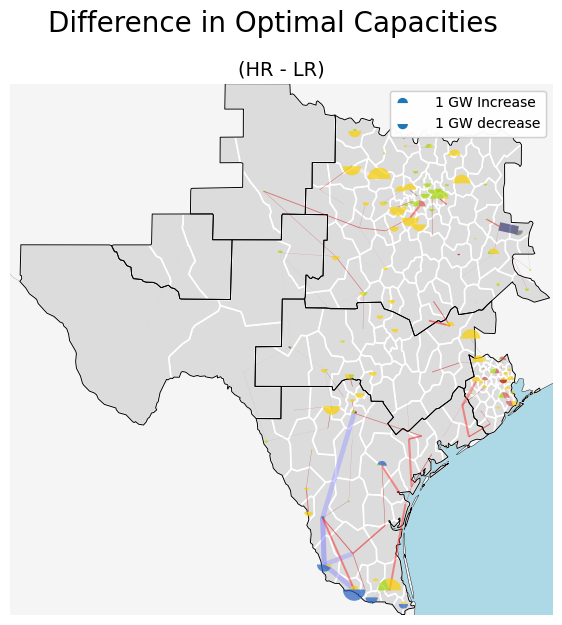

In [22]:
groupers = pypsa.statistics.groupers
def get_capacities(n: pypsa.Network):
    groupers = pypsa.statistics.groupers
    bus_capacities = n.statistics.optimal_capacity(groupby=groupers["bus", "carrier"], nice_names=False)
    bus_capacities = bus_capacities[bus_capacities.index.get_level_values('component') != 'Line']
    bus_capacities = bus_capacities.droplevel(0)
    bus_capacities = bus_capacities[n.investment_periods[0]]
    return bus_capacities

cap_id = get_capacities(n_hr_reactive)
cap_sq = get_capacities(n_lr_reactive)
diff_cap = cap_id - cap_sq

hr_reac_bus_diff, hr_reac_line_diff, hr_reac_link_diff = get_diff_capacities(n_hr_reactive)
lr_reac_bus_diff, lr_reac_line_diff, lr_reac_link_diff = get_diff_capacities(n_lr_reactive)

diff_line = hr_reac_line_diff - lr_reac_line_diff
diff_link = hr_reac_link_diff - lr_reac_link_diff

fig , axes = plt.subplots(1, 1, figsize=(7,7), subplot_kw={"projection": ccrs.EqualEarth(n_lr_reactive.buses.x.mean())})
# Plot data
bus_scale = 1e5

plot_capacity_map(
    n_lr_reactive,
    ax=axes,
    regions=regions,
    bus_values=diff_cap,
    link_values=diff_link,
    line_values=diff_line,
    bus_scale = 1e5,
    line_scale= line_scale,
    title="",
    link_colors="green",
    line_norm=None,
    line_alpha=0.5,
    bus_split_circles=True,
    line_colors=diff_line,
    line_cmap=colormap,
)

regions_lr.boundary.plot(
    ax=axes,
    facecolor=None,
    edgecolor="black",
    aspect="equal",
    transform=ccrs.PlateCarree(),
    linewidth=0.7,
)

plt.suptitle("Difference in Optimal Capacities", fontsize=TITLE_SIZE)
plt.title("(HR - LR)", fontsize=TITLE_SIZE * 0.7)

pypsa.plot.add_legend_semicircles(axes, sizes=[1e3/bus_scale, -1e3/bus_scale], labels=["1 GW Increase", "1 GW decrease"])

/Users/kamrantehranchi/miniforge3/envs/pypsa-usa/lib/python3.11/site-packages/pypsa/statistics/grouping.py:381: DeprecationWarning:

`n.statistics.get_bus_and_carrier` and `pypsa.statistics.get_bus_and_carrier` are deprecated. Use `pypsa.statistics.groupers["bus", "carrier"]` instead.

/Users/kamrantehranchi/miniforge3/envs/pypsa-usa/lib/python3.11/site-packages/pypsa/statistics/grouping.py:381: DeprecationWarning:

`n.statistics.get_bus_and_carrier` and `pypsa.statistics.get_bus_and_carrier` are deprecated. Use `pypsa.statistics.groupers["bus", "carrier"]` instead.

/Users/kamrantehranchi/miniforge3/envs/pypsa-usa/lib/python3.11/site-packages/pypsa/statistics/grouping.py:381: DeprecationWarning:

`n.statistics.get_bus_and_carrier` and `pypsa.statistics.get_bus_and_carrier` are deprecated. Use `pypsa.statistics.groupers["bus", "carrier"]` instead.

/Users/kamrantehranchi/miniforge3/envs/pypsa-usa/lib/python3.11/site-packages/pypsa/statistics/grouping.py:381: DeprecationWarning:

`n.sta

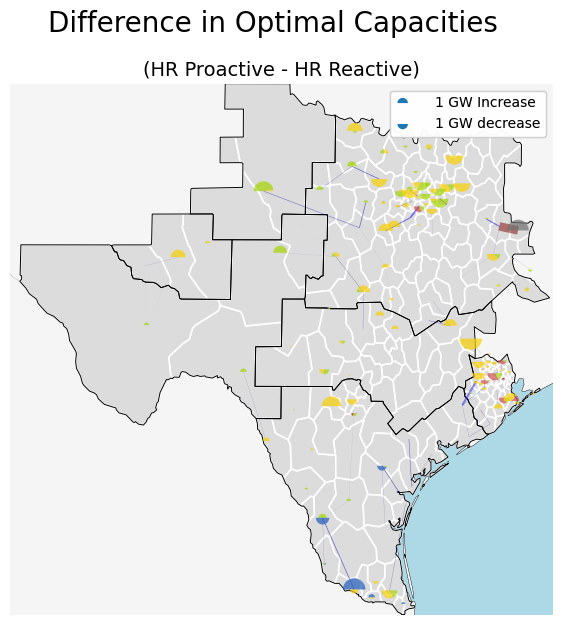

In [13]:
groupers = pypsa.statistics.groupers
def get_capacities(n: pypsa.Network):
    groupers = pypsa.statistics.groupers
    bus_capacities = n.statistics.optimal_capacity(groupby=groupers["bus", "carrier"], nice_names=False)
    bus_capacities = bus_capacities[bus_capacities.index.get_level_values('component') != 'Line']
    bus_capacities = bus_capacities.droplevel(0)
    bus_capacities = bus_capacities[n.investment_periods[0]]
    return bus_capacities

cap_id = get_capacities(n_hr_proactive)
cap_sq = get_capacities(n_hr_reactive)
diff_cap = cap_id - cap_sq

hr_reac_bus_diff, hr_reac_line_diff, hr_reac_link_diff = get_diff_capacities(n_hr_proactive)
lr_reac_bus_diff, sq_diff_line, sq_diff_link = get_diff_capacities(n_hr_reactive)

diff_line = hr_reac_line_diff - sq_diff_line
diff_link = hr_reac_link_diff - sq_diff_link

fig , axes = plt.subplots(1, 1, figsize=(7,7), subplot_kw={"projection": ccrs.EqualEarth(n_lr_reactive.buses.x.mean())})
# Plot data
bus_scale = 1e5

plot_capacity_map(
    n_hr_reactive,
    ax=axes,
    regions=regions,
    bus_values=diff_cap,
    link_values=diff_link,
    line_values=diff_line,
    bus_scale = 1e5,
    line_scale= line_scale,
    title="",
    link_colors="green",
    line_norm=None,
    line_alpha=0.5,
    bus_split_circles=True,
    line_colors=diff_line,
    line_cmap=colormap,
)

regions_lr.boundary.plot(
    ax=axes,
    facecolor=None,
    edgecolor="black",
    aspect="equal",
    transform=ccrs.PlateCarree(),
    linewidth=0.7,
)

plt.suptitle("Difference in Optimal Capacities", fontsize=TITLE_SIZE)
plt.title("(HR Proactive - HR Reactive)", fontsize=TITLE_SIZE * 0.7)

pypsa.plot.add_legend_semicircles(axes, sizes=[1e3/bus_scale, -1e3/bus_scale], labels=["1 GW Increase", "1 GW decrease"])

# PPT Figures

In [14]:
n_lr = pypsa.Network('/Users/kamrantehranchi/Local_Documents/pypsa-usa/workflow/notebooks/CH2/ppt_figures/elec_s210_c7a_ec_lv1.0_PRM-3h_E.nc')

INFO:pypsa.io:Imported network elec_s210_c7a_ec_lv1.0_PRM-3h_E.nc has buses, carriers, generators, global_constraints, lines, loads, storage_units


In [15]:
groupers = pypsa.statistics.groupers
def get_capacities(n: pypsa.Network, stat_type: str = "optimal_capacity"):
    groupers = pypsa.statistics.groupers
    # bus_capacities = n.statistics.optimal_capacity(groupby=groupers["bus", "carrier"], nice_names=False)
    bus_capacities = getattr(n.statistics, stat_type)(groupby=groupers["bus", "carrier"], nice_names=False)
    bus_capacities = bus_capacities[bus_capacities.index.get_level_values('component') != 'Line']
    bus_capacities = bus_capacities.droplevel(0)
    bus_capacities = bus_capacities[n.investment_periods[0]]
    return bus_capacities


## PLOT 1

/Users/kamrantehranchi/miniforge3/envs/pypsa-usa/lib/python3.11/site-packages/pypsa/statistics/grouping.py:381: DeprecationWarning:

`n.statistics.get_bus_and_carrier` and `pypsa.statistics.get_bus_and_carrier` are deprecated. Use `pypsa.statistics.groupers["bus", "carrier"]` instead.

/Users/kamrantehranchi/miniforge3/envs/pypsa-usa/lib/python3.11/site-packages/pypsa/statistics/grouping.py:381: DeprecationWarning:

`n.statistics.get_bus_and_carrier` and `pypsa.statistics.get_bus_and_carrier` are deprecated. Use `pypsa.statistics.groupers["bus", "carrier"]` instead.

/Users/kamrantehranchi/miniforge3/envs/pypsa-usa/lib/python3.11/site-packages/pypsa/statistics/grouping.py:381: DeprecationWarning:

`n.statistics.get_bus_and_carrier` and `pypsa.statistics.get_bus_and_carrier` are deprecated. Use `pypsa.statistics.groupers["bus", "carrier"]` instead.

/Users/kamrantehranchi/miniforge3/envs/pypsa-usa/lib/python3.11/site-packages/pypsa/statistics/grouping.py:381: DeprecationWarning:

`n.sta

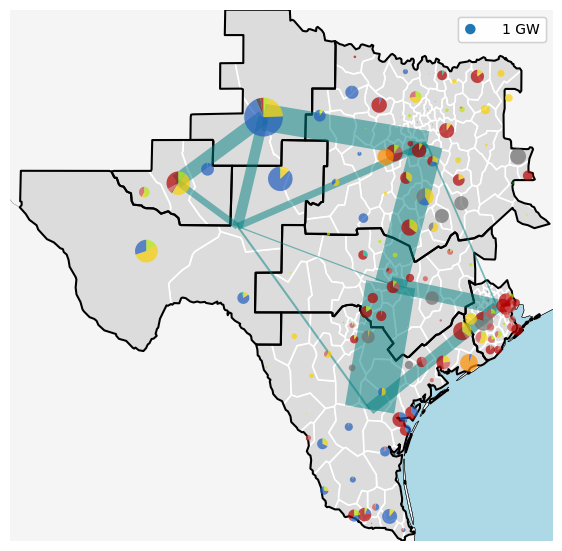

In [16]:

fig , axes = plt.subplots(1, 1, figsize=(7,7), subplot_kw={"projection": ccrs.EqualEarth(n_lr_reactive.buses.x.mean())})
# Plot data
bus_scale = 1e5
line_scale = 5e2

cap_id = get_capacities(n_lr)
hr_reac_bus_diff, hr_reac_line_diff, hr_reac_link_diff = get_diff_capacities(n_lr)

plot_capacity_map(
    n_lr,
    ax=axes,
    regions=regions,
    bus_values=0,
    link_values=n_lr.links.p_nom,
    line_values=n_lr.lines.s_nom,
    bus_scale = bus_scale,
    line_scale= line_scale,
    title="",
    link_colors="green",
    line_norm=None,
    line_alpha=0.5,
    bus_split_circles=True,
)

plot_capacity_map(
    n_hr_proactive,
    ax=axes,
    regions=regions,
    bus_values= get_capacities(n_hr_proactive, stat_type="installed_capacity"),
    link_values=hr_reac_link_diff * 0,
    line_values=hr_reac_line_diff * 0,
    bus_scale = 1e5,
    line_scale= line_scale,
    title="",
    link_colors="green",
    line_norm=None,
    line_alpha=0.5,
    bus_split_circles=False,
)

regions_lr.boundary.plot(
    ax=axes,
    facecolor=None,
    edgecolor="black",
    aspect="equal",
    transform=ccrs.PlateCarree(),
    linewidth=1.5,
)

plt.suptitle("", fontsize=TITLE_SIZE)
plt.title("", fontsize=TITLE_SIZE * 0.7)

pypsa.plot.add_legend_circles(axes, sizes=[1e3/bus_scale], labels=["1 GW"])

## PLOT 2

/Users/kamrantehranchi/miniforge3/envs/pypsa-usa/lib/python3.11/site-packages/cartopy/mpl/feature_artist.py:144: UserWarning:

facecolor will have no effect as it has been defined as "never".



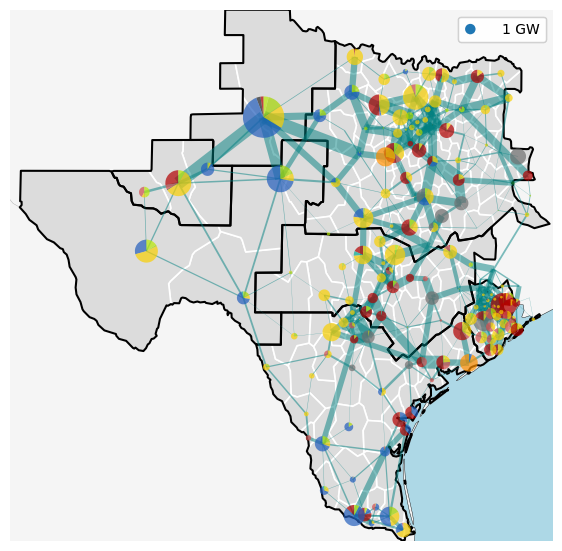

In [17]:
fig , axes = plt.subplots(1, 1, figsize=(7,7), subplot_kw={"projection": ccrs.EqualEarth(n_lr_reactive.buses.x.mean())})
# Plot data
bus_scale = 1e5
line_scale = 5e2

plot_capacity_map(
    n_hr_proactive,
    ax=axes,
    regions=regions,
    bus_values= get_capacities(n_hr_proactive, stat_type="optimal_capacity"),
    link_values=n_hr_proactive.links.p_nom,
    line_values=n_hr_proactive.lines.s_nom,
    bus_scale = 1e5,
    line_scale= line_scale,
    title="",
    link_colors="green",
    line_norm=None,
    line_alpha=0.5,
    bus_split_circles=False,
)

regions_lr.boundary.plot(
    ax=axes,
    facecolor=None,
    edgecolor="black",
    aspect="equal",
    transform=ccrs.PlateCarree(),
    linewidth=1.5,
)

plt.suptitle("", fontsize=TITLE_SIZE)
plt.title("", fontsize=TITLE_SIZE * 0.7)

pypsa.plot.add_legend_circles(axes, sizes=[1e3/bus_scale], labels=["1 GW"])

## PLOT 3

/Users/kamrantehranchi/miniforge3/envs/pypsa-usa/lib/python3.11/site-packages/pypsa/statistics/grouping.py:381: DeprecationWarning:

`n.statistics.get_bus_and_carrier` and `pypsa.statistics.get_bus_and_carrier` are deprecated. Use `pypsa.statistics.groupers["bus", "carrier"]` instead.

/Users/kamrantehranchi/miniforge3/envs/pypsa-usa/lib/python3.11/site-packages/pypsa/statistics/grouping.py:381: DeprecationWarning:

`n.statistics.get_bus_and_carrier` and `pypsa.statistics.get_bus_and_carrier` are deprecated. Use `pypsa.statistics.groupers["bus", "carrier"]` instead.

/Users/kamrantehranchi/miniforge3/envs/pypsa-usa/lib/python3.11/site-packages/pypsa/statistics/grouping.py:381: DeprecationWarning:

`n.statistics.get_bus_and_carrier` and `pypsa.statistics.get_bus_and_carrier` are deprecated. Use `pypsa.statistics.groupers["bus", "carrier"]` instead.

/Users/kamrantehranchi/miniforge3/envs/pypsa-usa/lib/python3.11/site-packages/pypsa/statistics/grouping.py:381: DeprecationWarning:

`n.sta

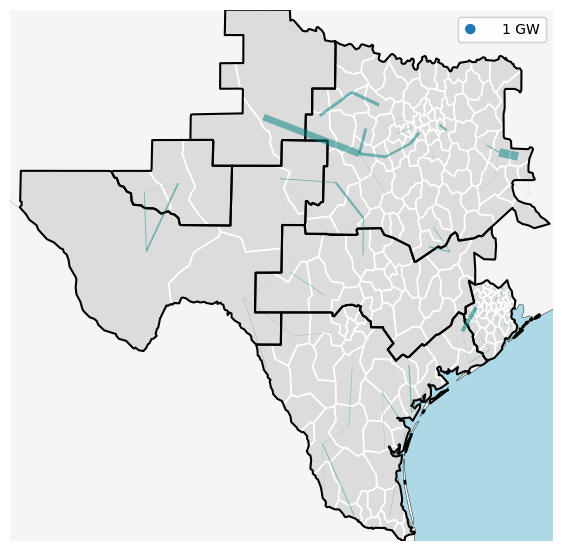

In [18]:
fig , axes = plt.subplots(1, 1, figsize=(7,7), subplot_kw={"projection": ccrs.EqualEarth(n_lr_reactive.buses.x.mean())})

bus_scale = 1e5
line_scale = 5e2

hr_reac_bus_diff, hr_reac_line_diff, hr_reac_link_diff = get_diff_capacities(n_hr_proactive)

plot_capacity_map(
    n_hr_proactive,
    ax=axes,
    regions=regions,
    bus_values= 0,
    link_values=hr_reac_link_diff,
    line_values=hr_reac_line_diff,
    bus_scale = 1e5,
    line_scale= line_scale,
    title="",
    link_colors="green",
    line_norm=None,
    line_alpha=0.5,
    bus_split_circles=False,
)

regions_lr.boundary.plot(
    ax=axes,
    facecolor=None,
    edgecolor="black",
    aspect="equal",
    transform=ccrs.PlateCarree(),
    linewidth=1.5,
)

plt.suptitle("", fontsize=TITLE_SIZE)
plt.title("", fontsize=TITLE_SIZE * 0.7)

pypsa.plot.add_legend_circles(axes, sizes=[1e3/bus_scale], labels=["1 GW"])